# 3.7 Dimension-Factor Correlation Analysis

This notebook identifies which latent dimensions are most strongly correlated with specific factors:
- **Age**: Continuous variable
- **Sex**: Binary variable (0=Female, 1=Male)
- **Handedness**: Categorical variable (1=Right, 2=Left)
- **Scanner**: Categorical variable (Manufacturer)
- **SBR**: Continuous variable (using SBR_PC1 as primary pathology measure)

## Objective
For each factor, identify:
1. The **single dimension** with the highest correlation
2. The **separation gap** between the top dimension and the 2nd-best dimension
3. Whether this top dimension is well-separated (indicating a clear signal)

## Methods
- **Pearson correlation**: For continuous variables (Age, SBR_PC1)
- **Point-biserial correlation**: For binary variables (Sex)
- **Eta-squared (η²)**: For categorical variables (Handedness, Scanner)
- **Separation metric**: Gap between 1st and 2nd ranked correlations

## Section 1: Setup and Data Loading

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from scipy import stats
from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Define Constants

In [2]:
FEATURE_COLS = [f'latent_{i}' for i in range(256)]
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

RANDOM_STATE = 42

print(f"Number of latent dimensions: {len(FEATURE_COLS)}")

Number of latent dimensions: 256


### 1.3 Load and Merge All Data

In [3]:
# Load merged clinical data
df_merged = pd.read_csv('output/merged_data.csv')
print(f"Merged clinical data: {df_merged.shape}")

# Load latent vectors
latent_file = 'output/Experiments/LatentVectorAnalysis/train_latent_vectors_with_patno.csv'
df_latent = pd.read_csv(latent_file)
print(f"Latent vectors: {df_latent.shape}")

# Load DICOM metadata for scanner info
df_dicom = pd.read_csv('data/csvData/dicom_metadata.csv')
print(f"DICOM metadata: {df_dicom.shape}")

Merged clinical data: (41816, 42)
Latent vectors: (2340, 260)
DICOM metadata: (2986, 6)


In [4]:
df_latent_clean = df_latent.dropna(subset=['FilePath']).copy()
df_latent_clean.shape

(2340, 260)

In [5]:
df_dicom.rename(columns={'file_path': 'FilePath'}, inplace=True)
df_dicom_latest = df_dicom.dropna(subset=['FilePath']).copy()
df_dicom_latest.shape

(2986, 6)

In [6]:
print("--- Latent DataFrame Path Example ---")
print(df_latent_clean['FilePath'].iloc[0])

print("\n--- DICOM DataFrame Path Example ---")
print(df_dicom_latest['FilePath'].iloc[0])

--- Latent DataFrame Path Example ---
data/Images/PPMI_Images_PD/120403/Reconstructed_DaTSCAN/2022-01-07_12_25_23.0/I1542909/PPMI_120403_NM_Reconstructed_DaTSCAN_Br_20220209142608900_1_S1103411_I1542909.dcm

--- DICOM DataFrame Path Example ---
Images\PPMI_Images_PD\100001\Reconstructed_DaTSCAN\2020-09-09_17_07_33.0\I1452480\PPMI_100001_NM_Reconstructed_DaTSCAN_Br_20210608102518754_1_S1028880_I1452480.dcm


In [7]:
# Function to normalize paths
def normalize_path(path_str):
    if pd.isna(path_str): return path_str
    
    # 1. Force forward slashes
    clean_p = path_str.replace('\\', '/')
    
    # 2. Remove 'data/' prefix if it exists to ensure matching
    if clean_p.startswith('data/'):
        clean_p = clean_p.replace('data/', '')
        
    # 3. Strip any leading/trailing whitespace
    return clean_p.strip()

# Apply to BOTH dataframes
df_latent_clean['Merge_Key'] = df_latent_clean['FilePath'].apply(normalize_path)
df_dicom_latest['Merge_Key'] = df_dicom_latest['FilePath'].apply(normalize_path)

# Check if they look the same now
print("New Key Latent:", df_latent_clean['Merge_Key'].iloc[0])
print("New Key DICOM: ", df_dicom_latest['Merge_Key'].iloc[0])

New Key Latent: Images/PPMI_Images_PD/120403/Reconstructed_DaTSCAN/2022-01-07_12_25_23.0/I1542909/PPMI_120403_NM_Reconstructed_DaTSCAN_Br_20220209142608900_1_S1103411_I1542909.dcm
New Key DICOM:  Images/PPMI_Images_PD/100001/Reconstructed_DaTSCAN/2020-09-09_17_07_33.0/I1452480/PPMI_100001_NM_Reconstructed_DaTSCAN_Br_20210608102518754_1_S1028880_I1452480.dcm


In [8]:
df_latent_with_scanner = pd.merge(
    df_latent_clean,
    df_dicom_latest[['Merge_Key', 'Manufacturer', 'ManufacturerModelName']],
    on='Merge_Key',
    how='left'  # Keep all latent vectors, add scanner info
)
df_latent_with_scanner.shape

(2340, 263)

In [9]:
df_latent_with_scanner.sample(5)

,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,latent_16,latent_17,latent_18,latent_19,latent_20,latent_21,latent_22,latent_23,latent_24,latent_25,latent_26,latent_27,latent_28,latent_29,latent_30,latent_31,latent_32,latent_33,latent_34,latent_35,latent_36,latent_37,latent_38,latent_39,latent_40,latent_41,latent_42,latent_43,latent_44,latent_45,latent_46,latent_47,latent_48,latent_49,latent_50,latent_51,latent_52,latent_53,latent_54,latent_55,latent_56,latent_57,latent_58,latent_59,latent_60,latent_61,latent_62,latent_63,latent_64,latent_65,latent_66,latent_67,latent_68,latent_69,latent_70,latent_71,latent_72,latent_73,latent_74,latent_75,latent_76,latent_77,latent_78,latent_79,latent_80,latent_81,latent_82,latent_83,latent_84,latent_85,latent_86,latent_87,latent_88,latent_89,latent_90,latent_91,latent_92,latent_93,latent_94,latent_95,latent_96,latent_97,latent_98,latent_99,latent_100,latent_101,latent_102,latent_103,latent_104,latent_105,latent_106,latent_107,latent_108,latent_109,latent_110,latent_111,latent_112,latent_113,latent_114,latent_115,latent_116,latent_117,latent_118,latent_119,latent_120,latent_121,latent_122,latent_123,latent_124,latent_125,latent_126,latent_127,latent_128,latent_129,latent_130,latent_131,latent_132,latent_133,latent_134,latent_135,latent_136,latent_137,latent_138,latent_139,latent_140,latent_141,latent_142,latent_143,latent_144,latent_145,latent_146,latent_147,latent_148,latent_149,latent_150,latent_151,latent_152,latent_153,latent_154,latent_155,latent_156,latent_157,latent_158,latent_159,latent_160,latent_161,latent_162,latent_163,latent_164,latent_165,latent_166,latent_167,latent_168,latent_169,latent_170,latent_171,latent_172,latent_173,latent_174,latent_175,latent_176,latent_177,latent_178,latent_179,latent_180,latent_181,latent_182,latent_183,latent_184,latent_185,latent_186,latent_187,latent_188,latent_189,latent_190,latent_191,latent_192,latent_193,latent_194,latent_195,latent_196,latent_197,latent_198,latent_199,latent_200,latent_201,latent_202,latent_203,latent_204,latent_205,latent_206,latent_207,latent_208,latent_209,latent_210,latent_211,latent_212,latent_213,latent_214,latent_215,latent_216,latent_217,latent_218,latent_219,latent_220,latent_221,latent_222,latent_223,latent_224,latent_225,latent_226,latent_227,latent_228,latent_229,latent_230,latent_231,latent_232,latent_233,latent_234,latent_235,latent_236,latent_237,latent_238,latent_239,latent_240,latent_241,latent_242,latent_243,latent_244,latent_245,latent_246,latent_247,latent_248,latent_249,latent_250,latent_251,latent_252,latent_253,latent_254,latent_255,Label,FilePath,PATNO,Dataset,Merge_Key,Manufacturer,ManufacturerModelName
797,-0.693383,-16.478394,-1.364018,-2.782903,-0.958081,5.998697,3.384969,1.532524,-2.561950,1.568080,2.536705,3.704490,-1.010087,0.160663,2.090236,16.672130,0.078494,3.751208,-0.308180,5.650551,0.487021,-2.893600,2.381265,16.892942,-5.167304,4.251567,-6.838994,1.195969,-1.156024,-0.381581,3.218509,-0.586401,2.667386,1.638367,5.864042,1.981971,-4.025268,1.289209,-1.208975,5.319825,0.563130,-7.532328,3.031040,-13.718618,-2.304307,8.609787,-0.154426,-1.051492,3.686461,0.419465,1.166358,-1.971715,1.636407,-4.809099,-0.505785,-4.370403,3.285033,2.437505,-3.470355,0.764159,-0.394350,21.687191,5.608478,-1.637996,-9.805305,-2.962767,2.081585,-1.041148,-0.177460,-1.293675,-4.422012,-6.165240,0.731358,8.427720,-1.844498,1.399436,3.384704,5.334241,0.912696,1.565085,-2.797541,-2.115799,-5.467350,-7.908611,4.533696,-5.606902,1.429541,-1.245856,2.766646,1.297494,-0.789370,0.748611,0.395002,5.024154,-0.074992,0.008301,-11.696901,2.131166,1.495593,-3.264518,-0.895876,-11.119886,2.364592,1.290018,-2.023391,0.390948,0.459087,9.161427,-2.450844,-4.563923,0.614011,-5.849145,-9.006141,-1.188939,-3.378662,-0.443899,1.683518,3.449031,1.520277,1.215658,1.611668,-0.985028,2.835273,-0.724286,-1.433189,0.418026,-4.432807,0.806

In [10]:
# 1. Robust Date Extraction (Finds YYYY-MM-DD anywhere in path)
def get_date_from_path(path_str):
    # Regex to find pattern: 4 digits - 2 digits - 2 digits
    match = re.search(r'(\d{4}-\d{2}-\d{2})', str(path_str))
    if match:
        date_raw = match.group(1) # Extracts '2021-04-06'
        try:
            return datetime.strptime(date_raw, '%Y-%m-%d').strftime('%m/%Y')
        except:
            return None
    return None

# 2. Apply the fix
df_latent_with_scanner['DATSCAN_DATE'] = df_latent_with_scanner['FilePath'].apply(get_date_from_path)

# Verify we actually have dates now (Should NOT be None)
print("Latent Date Sample:", df_latent_with_scanner['DATSCAN_DATE'].dropna().iloc[0]) 

# 3. Clean Clinical Data (df_merged)
# Ensure PATNO is int and Date is formatted
df_merged['PATNO'] = pd.to_numeric(df_merged['PATNO'], errors='coerce').fillna(0).astype(int)
df_latent_with_scanner['PATNO'] = pd.to_numeric(df_latent_with_scanner['PATNO'], errors='coerce').fillna(0).astype(int)

# convert clinical dates to strings, handle NaNs
df_merged['DATSCAN_DATE'] = pd.to_datetime(df_merged['DATSCAN_DATE'], errors='coerce').dt.strftime('%m/%Y')

# 4. Perform the Merge (Inner Join to test matches)
df_combined = pd.merge(
    df_latent_with_scanner, 
    df_merged, 
    on=['PATNO', 'DATSCAN_DATE'], 
    how='inner'
)

print(f"Merge Shape: {df_combined.shape}")

Latent Date Sample: 01/2022
Merge Shape: (2332, 304)


### 1.4 Calculate SBR Principal Components

In [11]:
# Filter to rows with complete SBR data
df_with_sbr = df_combined.dropna(subset=SBR_COLS).copy()
print(f"Rows with complete SBR data: {len(df_with_sbr)}")

# Standardize and apply PCA
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=RANDOM_STATE)
sbr_pcs = pca.fit_transform(sbr_scaled)

df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

print(f"\nSBR PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Use this as final dataset
df_final = df_with_sbr.reset_index(drop=True)
print(f"\nFinal dataset: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")

Rows with complete SBR data: 2332

SBR PCA explained variance: [0.88358199 0.05366807 0.04735171]
Total variance explained: 98.46%

Final dataset: (2332, 307)
Unique patients: 1406


### 1.5 Check Available Factors

In [12]:
print("Factor Availability Check:")
print("="*80)

# Age
age_available = df_final['AGE_AT_VISIT'].notna().sum()
print(f"\nAge (AGE_AT_VISIT):")
print(f"  Available: {age_available}/{len(df_final)} ({age_available/len(df_final)*100:.1f}%)")
if age_available > 0:
    print(f"  Range: [{df_final['AGE_AT_VISIT'].min():.0f}, {df_final['AGE_AT_VISIT'].max():.0f}]")
    print(f"  Mean: {df_final['AGE_AT_VISIT'].mean():.1f}")

# Sex
sex_available = df_final['SEX'].notna().sum()
print(f"\nSex:")
print(f"  Available: {sex_available}/{len(df_final)} ({sex_available/len(df_final)*100:.1f}%)")
if sex_available > 0:
    print(f"  Distribution:\n{df_final['SEX'].value_counts()}")

# Handedness
handed_available = df_final['HANDED'].notna().sum()
print(f"\nHandedness:")
print(f"  Available: {handed_available}/{len(df_final)} ({handed_available/len(df_final)*100:.1f}%)")
if handed_available > 0:
    print(f"  Distribution:\n{df_final['HANDED'].value_counts()}")


# Scanner
scanner_available = df_final['Manufacturer'].notna().sum()
print(f"\nScanner (Manufacturer):")
print(f"  Available: {scanner_available}/{len(df_final)} ({scanner_available/len(df_final)*100:.1f}%)")
if scanner_available > 0:
    print(f"  Unique manufacturers: {df_final['Manufacturer'].nunique()}")
    print(f"  Top 5:\n{df_final['Manufacturer'].value_counts().head()}")

# SBR
sbr_available = df_final['SBR_PC1'].notna().sum()
print(f"\nSBR (SBR_PC1):")
print(f"  Available: {sbr_available}/{len(df_final)} ({sbr_available/len(df_final)*100:.1f}%)")
if sbr_available > 0:
    print(f"  Range: [{df_final['SBR_PC1'].min():.2f}, {df_final['SBR_PC1'].max():.2f}]")
    print(f"  Mean: {df_final['SBR_PC1'].mean():.2f}")

Factor Availability Check:

Age (AGE_AT_VISIT):
  Available: 2331/2332 (100.0%)
  Range: [31, 89]
  Mean: 63.5

Sex:
  Available: 2331/2332 (100.0%)
  Distribution:
SEX
1.0    1451
0.0     880
Name: count, dtype: int64

Handedness:
  Available: 2330/2332 (99.9%)
  Distribution:
HANDED
1.0    2030
2.0     225
3.0      75
Name: count, dtype: int64

Scanner (Manufacturer):
  Available: 2331/2332 (100.0%)
  Unique manufacturers: 15
  Top 5:
Manufacturer
SIEMENS NM                              1169
GE MEDICAL SYSTEMS                       456
Marconi Medical Systems, NM Division     268
PICKER                                   119
Philips Nuclear Medicine                  90
Name: count, dtype: int64

SBR (SBR_PC1):
  Available: 2332/2332 (100.0%)
  Range: [-4.54, 11.22]
  Mean: 0.00


## Section 2: Correlation Analysis Functions

### 2.1 Define Correlation Functions

In [13]:
def compute_continuous_correlations(X, y, feature_names):
    """
    Compute Pearson correlations between features (X) and continuous target (y).
    Returns DataFrame with correlations, p-values, and absolute correlations.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | np.isnan(y))
        if mask.sum() < 3:
            continue
            
        r, p = stats.pearsonr(X[mask, i], y[mask])
        results.append({
            'Feature': feature,
            'Correlation': r,
            'P_Value': p,
            'Abs_Correlation': abs(r)
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Abs_Correlation', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


def compute_binary_correlations(X, y, feature_names):
    """
    Compute point-biserial correlations between features (X) and binary target (y).
    Returns DataFrame with correlations, p-values, and absolute correlations.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | np.isnan(y))
        if mask.sum() < 3:
            continue
            
        r, p = pointbiserialr(y[mask], X[mask, i])
        results.append({
            'Feature': feature,
            'Correlation': r,
            'P_Value': p,
            'Abs_Correlation': abs(r)
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Abs_Correlation', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


def compute_categorical_associations(X, y, feature_names):
    """
    Compute eta-squared (η²) for association between features (X) and categorical target (y).
    η² represents the proportion of variance in the feature explained by the category.
    Returns DataFrame with eta-squared values.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | pd.isna(y))
        if mask.sum() < 3:
            continue
        
        x_clean = X[mask, i]
        y_clean = y[mask]
        
        # Get unique categories
        categories = np.unique(y_clean)
        if len(categories) < 2:
            continue
        
        # Compute ANOVA
        groups = [x_clean[y_clean == cat] for cat in categories]
        f_stat, p_val = stats.f_oneway(*groups)
        
        # Compute eta-squared
        grand_mean = x_clean.mean()
        ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
        ss_total = sum((x_clean - grand_mean)**2)
        eta_squared = ss_between / ss_total if ss_total > 0 else 0
        
        results.append({
            'Feature': feature,
            'Eta_Squared': eta_squared,
            'F_Statistic': f_stat,
            'P_Value': p_val
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Eta_Squared', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


print("Correlation functions defined successfully!")

Correlation functions defined successfully!


### 2.2 Define Separation Analysis Function

In [14]:
def analyze_separation(df_corr, metric_col='Abs_Correlation', top_n=10):
    """
    Analyze separation between top-ranked features.
    Returns summary statistics and separation gap.
    """
    if len(df_corr) < 2:
        return None
    
    top_feature = df_corr.iloc[0]
    second_feature = df_corr.iloc[1]
    
    gap = top_feature[metric_col] - second_feature[metric_col]
    gap_pct = (gap / top_feature[metric_col] * 100) if top_feature[metric_col] > 0 else 0
    
    summary = {
        'Top_Feature': top_feature['Feature'],
        'Top_Value': top_feature[metric_col],
        'Second_Feature': second_feature['Feature'],
        'Second_Value': second_feature[metric_col],
        'Gap': gap,
        'Gap_Percent': gap_pct,
        'Top_N_Features': df_corr.head(top_n)['Feature'].tolist(),
        'Top_N_Values': df_corr.head(top_n)[metric_col].tolist()
    }
    
    return summary


print("Separation analysis function defined!")

Separation analysis function defined!


## Section 3: Factor-by-Factor Analysis

### 3.1 Extract Latent Features

In [15]:
# Extract latent features matrix
X_latent = df_final[FEATURE_COLS].values
print(f"Latent features matrix shape: {X_latent.shape}")
print(f"Missing values: {np.isnan(X_latent).sum()}")

Latent features matrix shape: (2332, 256)
Missing values: 0


### 3.2 Age Analysis

In [16]:
print("="*80)
print("FACTOR 1: AGE")
print("="*80)

y_age = df_final['AGE_AT_VISIT'].values
print(f"\nSamples with valid age: {(~np.isnan(y_age)).sum()}")

# Compute correlations
df_age_corr = compute_continuous_correlations(X_latent, y_age, FEATURE_COLS)

# Analyze separation
age_sep = analyze_separation(df_age_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {age_sep['Top_Feature']}")
print(f"  Correlation: {age_sep['Top_Value']:.4f}")
print(f"  P-value: {df_age_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {age_sep['Second_Feature']}")
print(f"  Correlation: {age_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {age_sep['Gap']:.4f}")
print(f"  Relative: {age_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_age_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))

FACTOR 1: AGE

Samples with valid age: 2331

Top dimension: latent_189
  Correlation: 0.4030
  P-value: 9.8853e-92

Second-best dimension: latent_208
  Correlation: 0.3294

Separation Gap:
  Absolute: 0.0735
  Relative: 18.3%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation      P_Value
    1 latent_189    -0.402975         0.402975 9.885345e-92
    2 latent_208    -0.329432         0.329432 3.989213e-60
    3 latent_130     0.307303         0.307303 3.645745e-52
    4 latent_136    -0.303071         0.303071 1.019313e-50
    5 latent_249     0.296402         0.296402 1.734672e-48
    6  latent_80    -0.269921         0.269921 3.363694e-40
    7 latent_101     0.265114         0.265114 8.621080e-39
    8 latent_176     0.261404         0.261404 1.006942e-37
    9 latent_203    -0.236093         0.236093 6.860416e-31
   10  latent_19    -0.232630         0.232630 5.144504e-30


### 3.3 Sex Analysis

In [17]:
print("\n" + "="*80)
print("FACTOR 2: SEX")
print("="*80)

y_sex = df_final['SEX'].values
print(f"\nSamples with valid sex: {(~np.isnan(y_sex)).sum()}")
print(f"Distribution: Female={(y_sex==0).sum()}, Male={(y_sex==1).sum()}")

# Compute correlations
df_sex_corr = compute_binary_correlations(X_latent, y_sex, FEATURE_COLS)

# Analyze separation
sex_sep = analyze_separation(df_sex_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {sex_sep['Top_Feature']}")
print(f"  Correlation: {sex_sep['Top_Value']:.4f}")
print(f"  P-value: {df_sex_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {sex_sep['Second_Feature']}")
print(f"  Correlation: {sex_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {sex_sep['Gap']:.4f}")
print(f"  Relative: {sex_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_sex_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))


FACTOR 2: SEX

Samples with valid sex: 2331
Distribution: Female=880, Male=1451

Top dimension: latent_189
  Correlation: 0.2401
  P-value: 6.3475e-32

Second-best dimension: latent_208
  Correlation: 0.2331

Separation Gap:
  Absolute: 0.0071
  Relative: 2.9%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation      P_Value
    1 latent_189    -0.240114         0.240114 6.347497e-32
    2 latent_208    -0.233054         0.233054 4.026968e-30
    3  latent_92     0.204708         0.204708 1.791241e-23
    4  latent_44    -0.201876         0.201876 7.353120e-23
    5 latent_152     0.198802         0.198802 3.325980e-22
    6  latent_71     0.194822         0.194822 2.263027e-21
    7 latent_191     0.193062         0.193062 5.215618e-21
    8 latent_176     0.191184         0.191184 1.260149e-20
    9  latent_48    -0.178615         0.178615 3.658404e-18
   10 latent_141    -0.164646         0.164646 1.248603e-15


### 3.4 Handedness Analysis

In [18]:
print("\n" + "="*80)
print("FACTOR 3: HANDEDNESS")
print("="*80)

y_hand = df_final["HANDED"].values
valid_hand = pd.notna(y_hand)
print(f"\nSamples with valid handedness: {valid_hand.sum()}")

if valid_hand.sum() > 0:
    print(f"Distribution:\n{pd.Series(y_hand).value_counts()}")
    
    # Categorical - use eta-squared
    print("\nTreating as categorical variable...")
    df_hand_corr = compute_categorical_associations(X_latent, y_hand, FEATURE_COLS)
    metric_col = 'Eta_Squared'
    
    # Analyze separation
    hand_sep = analyze_separation(df_hand_corr, metric_col=metric_col, top_n=10)
    
    print(f"\nTop dimension: {hand_sep['Top_Feature']}")
    print(f"  {metric_col}: {hand_sep['Top_Value']:.4f}")
    print(f"  P-value: {df_hand_corr.iloc[0]['P_Value']:.4e}")
    
    print(f"\nSecond-best dimension: {hand_sep['Second_Feature']}")
    print(f"  {metric_col}: {hand_sep['Second_Value']:.4f}")
    
    print(f"\nSeparation Gap:")
    print(f"  Absolute: {hand_sep['Gap']:.4f}")
    print(f"  Relative: {hand_sep['Gap_Percent']:.1f}%")
    
    print(f"\nTop 10 dimensions:")
    print(df_hand_corr.head(10).to_string(index=False))


FACTOR 3: HANDEDNESS

Samples with valid handedness: 2330
Distribution:
1.0    2030
2.0     225
3.0      75
Name: count, dtype: int64

Treating as categorical variable...

Top dimension: latent_63
  Eta_Squared: 0.0089
  P-value: 3.1872e-05

Second-best dimension: latent_58
  Eta_Squared: 0.0073

Separation Gap:
  Absolute: 0.0016
  Relative: 17.8%

Top 10 dimensions:
   Feature  Eta_Squared  F_Statistic  P_Value  Rank
 latent_63     0.008859    10.399972 0.000032     1
 latent_58     0.007285     8.538621 0.000202     2
latent_204     0.005598     6.550244 0.001456     3
  latent_7     0.005008     5.855858 0.002905     4
 latent_29     0.004859     5.680947 0.003458     5
 latent_65     0.004406     5.149460 0.005869     6
 latent_96     0.004253     4.969682 0.007019     7
latent_211     0.004159     4.859304 0.007835     8
 latent_77     0.003978     4.646512 0.009684     9
 latent_53     0.003903     4.558644 0.010570    10


### 3.5 Scanner Analysis

In [19]:
print("\n" + "="*80)
print("FACTOR 4: SCANNER (Manufacturer)")
print("="*80)

y_scanner = df_final['Manufacturer'].values
valid_scanner = pd.notna(y_scanner)
print(f"\nSamples with valid scanner: {valid_scanner.sum()}")
print(f"Unique manufacturers: {pd.Series(y_scanner).nunique()}")
print(f"\nTop 5 manufacturers:\n{pd.Series(y_scanner).value_counts().head()}")

# Compute eta-squared
df_scanner_corr = compute_categorical_associations(X_latent, y_scanner, FEATURE_COLS)

# Analyze separation
scanner_sep = analyze_separation(df_scanner_corr, metric_col='Eta_Squared', top_n=10)

print(f"\nTop dimension: {scanner_sep['Top_Feature']}")
print(f"  Eta-squared: {scanner_sep['Top_Value']:.4f}")
print(f"  P-value: {df_scanner_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {scanner_sep['Second_Feature']}")
print(f"  Eta-squared: {scanner_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {scanner_sep['Gap']:.4f}")
print(f"  Relative: {scanner_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_scanner_corr.head(10).to_string(index=False))


FACTOR 4: SCANNER (Manufacturer)

Samples with valid scanner: 2331
Unique manufacturers: 15

Top 5 manufacturers:
SIEMENS NM                              1169
GE MEDICAL SYSTEMS                       456
Marconi Medical Systems, NM Division     268
PICKER                                   119
Philips Nuclear Medicine                  90
Name: count, dtype: int64

Top dimension: latent_43
  Eta-squared: 0.1868
  P-value: 1.5147e-93

Second-best dimension: latent_255
  Eta-squared: 0.1669

Separation Gap:
  Absolute: 0.0199
  Relative: 10.6%

Top 10 dimensions:
   Feature  Eta_Squared  F_Statistic      P_Value  Rank
 latent_43     0.186799    38.000206 1.514665e-93     1
latent_255     0.166931    33.148747 1.066050e-81     2
latent_140     0.163129    32.246641 1.811033e-79     3
 latent_85     0.160545    31.638055 5.851324e-78     4
 latent_31     0.148412    28.830370 6.030967e-71     5
latent_213     0.146468    28.388016 7.811740e-70     6
 latent_98     0.134288    25.660969 6.22

### 3.6 SBR Analysis

In [20]:
print("\n" + "="*80)
print("FACTOR 5: SBR (SBR_PC1)")
print("="*80)

y_sbr = df_final['SBR_PC1'].values
print(f"\nSamples with valid SBR: {(~np.isnan(y_sbr)).sum()}")
print(f"SBR_PC1 range: [{np.nanmin(y_sbr):.2f}, {np.nanmax(y_sbr):.2f}]")
print(f"SBR_PC1 mean: {np.nanmean(y_sbr):.2f}")

# Compute correlations
df_sbr_corr = compute_continuous_correlations(X_latent, y_sbr, FEATURE_COLS)

# Analyze separation
sbr_sep = analyze_separation(df_sbr_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {sbr_sep['Top_Feature']}")
print(f"  Correlation: {sbr_sep['Top_Value']:.4f}")
print(f"  P-value: {df_sbr_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {sbr_sep['Second_Feature']}")
print(f"  Correlation: {sbr_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {sbr_sep['Gap']:.4f}")
print(f"  Relative: {sbr_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_sbr_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))


FACTOR 5: SBR (SBR_PC1)

Samples with valid SBR: 2332
SBR_PC1 range: [-4.54, 11.22]
SBR_PC1 mean: 0.00

Top dimension: latent_5
  Correlation: 0.9317
  P-value: 0.0000e+00

Second-best dimension: latent_93
  Correlation: 0.9237

Separation Gap:
  Absolute: 0.0080
  Relative: 0.9%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation       P_Value
    1   latent_5    -0.931738         0.931738  0.000000e+00
    2  latent_93    -0.923707         0.923707  0.000000e+00
    3 latent_251     0.823531         0.823531  0.000000e+00
    4   latent_1    -0.757189         0.757189  0.000000e+00
    5 latent_155     0.716442         0.716442  0.000000e+00
    6  latent_73    -0.630395         0.630395 1.424452e-258
    7  latent_44     0.607699         0.607699 1.697090e-235
    8 latent_116     0.592437         0.592437 5.299969e-221
    9 latent_170     0.566886         0.566886 2.109471e-198
   10  latent_61     0.563184         0.563184 2.733681e-195


## Section 4: Summary and Visualization

### 4.1 Create Summary Table

In [21]:
print("\n" + "="*80)
print("SUMMARY: TOP DIMENSION FOR EACH FACTOR")
print("="*80)

summary_data = []

# Age
summary_data.append({
    'Factor': 'Age',
    'Top_Dimension': age_sep['Top_Feature'],
    'Metric': 'Pearson r',
    'Top_Value': age_sep['Top_Value'],
    'Second_Value': age_sep['Second_Value'],
    'Gap': age_sep['Gap'],
    'Gap_Percent': age_sep['Gap_Percent'],
    'P_Value': df_age_corr.iloc[0]['P_Value']
})

# Sex
summary_data.append({
    'Factor': 'Sex',
    'Top_Dimension': sex_sep['Top_Feature'],
    'Metric': 'Point-biserial r',
    'Top_Value': sex_sep['Top_Value'],
    'Second_Value': sex_sep['Second_Value'],
    'Gap': sex_sep['Gap'],
    'Gap_Percent': sex_sep['Gap_Percent'],
    'P_Value': df_sex_corr.iloc[0]['P_Value']
})

# Handedness (if available)
if hand_sep is not None:
    metric_name = 'Eta²' if 'Eta_Squared' in df_hand_corr.columns else 'Point-biserial r'
    summary_data.append({
        'Factor': 'Handedness',
        'Top_Dimension': hand_sep['Top_Feature'],
        'Metric': metric_name,
        'Top_Value': hand_sep['Top_Value'],
        'Second_Value': hand_sep['Second_Value'],
        'Gap': hand_sep['Gap'],
        'Gap_Percent': hand_sep['Gap_Percent'],
        'P_Value': df_hand_corr.iloc[0]['P_Value']
    })

# Scanner
summary_data.append({
    'Factor': 'Scanner',
    'Top_Dimension': scanner_sep['Top_Feature'],
    'Metric': 'Eta²',
    'Top_Value': scanner_sep['Top_Value'],
    'Second_Value': scanner_sep['Second_Value'],
    'Gap': scanner_sep['Gap'],
    'Gap_Percent': scanner_sep['Gap_Percent'],
    'P_Value': df_scanner_corr.iloc[0]['P_Value']
})

# SBR
summary_data.append({
    'Factor': 'SBR',
    'Top_Dimension': sbr_sep['Top_Feature'],
    'Metric': 'Pearson r',
    'Top_Value': sbr_sep['Top_Value'],
    'Second_Value': sbr_sep['Second_Value'],
    'Gap': sbr_sep['Gap'],
    'Gap_Percent': sbr_sep['Gap_Percent'],
    'P_Value': df_sbr_corr.iloc[0]['P_Value']
})

df_summary = pd.DataFrame(summary_data)
print("\n", df_summary.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("\nSeparation Quality:")
for _, row in df_summary.iterrows():
    quality = "EXCELLENT" if row['Gap_Percent'] > 20 else "GOOD" if row['Gap_Percent'] > 10 else "MODERATE" if row['Gap_Percent'] > 5 else "WEAK"
    print(f"  {row['Factor']}: {quality} separation ({row['Gap_Percent']:.1f}% gap)")


SUMMARY: TOP DIMENSION FOR EACH FACTOR

     Factor Top_Dimension           Metric  Top_Value  Second_Value      Gap  Gap_Percent      P_Value
       Age    latent_189        Pearson r   0.402975      0.329432 0.073543    18.250013 9.885345e-92
       Sex    latent_189 Point-biserial r   0.240114      0.233054 0.007060     2.940228 6.347497e-32
Handedness     latent_63             Eta²   0.008859      0.007285 0.001574    17.767273 3.187249e-05
   Scanner     latent_43             Eta²   0.186799      0.166931 0.019867    10.635730 1.514665e-93
       SBR      latent_5        Pearson r   0.931738      0.923707 0.008030     0.861859 0.000000e+00

INTERPRETATION

Separation Quality:
  Age: GOOD separation (18.3% gap)
  Sex: WEAK separation (2.9% gap)
  Handedness: GOOD separation (17.8% gap)
  Scanner: GOOD separation (10.6% gap)
  SBR: WEAK separation (0.9% gap)


### 4.2 Visualization: Top Dimensions and Separation Gaps

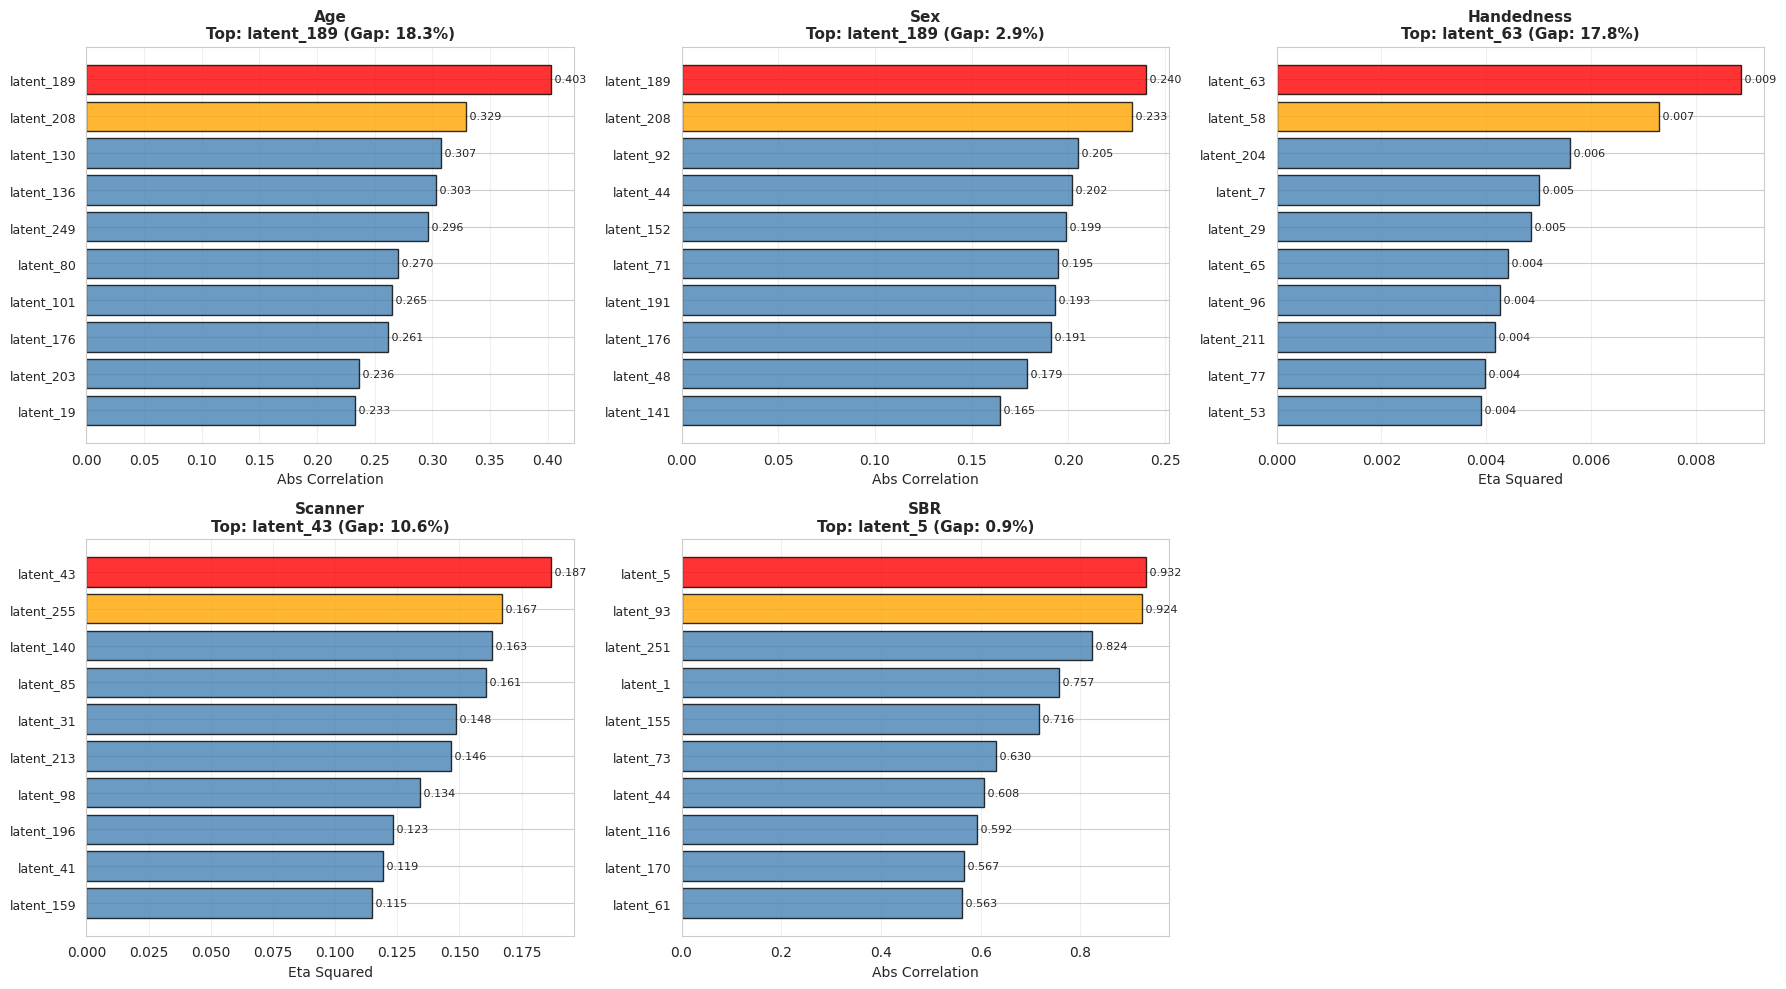

Plot saved to: output/dimension_factor_correlation_top10.png


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot for each factor
plot_data = [
    ('Age', df_age_corr, age_sep, 'Abs_Correlation'),
    ('Sex', df_sex_corr, sex_sep, 'Abs_Correlation'),
    ('Handedness', df_hand_corr, hand_sep, 'Eta_Squared' if df_hand_corr is not None and 'Eta_Squared' in df_hand_corr.columns else 'Abs_Correlation'),
    ('Scanner', df_scanner_corr, scanner_sep, 'Eta_Squared'),
    ('SBR', df_sbr_corr, sbr_sep, 'Abs_Correlation')
]

for idx, (factor_name, df_corr, sep, metric_col) in enumerate(plot_data):
    if df_corr is None or sep is None:
        axes[idx].text(0.5, 0.5, f'{factor_name}\nNo data available', 
                      ha='center', va='center', fontsize=12)
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])
        continue
    
    # Get top 10
    top_10 = df_corr.head(10)
    
    # Create bar plot
    colors = ['red' if i == 0 else 'orange' if i == 1 else 'steelblue' for i in range(len(top_10))]
    bars = axes[idx].barh(range(len(top_10)), top_10[metric_col], color=colors, edgecolor='black', alpha=0.8)
    
    axes[idx].set_yticks(range(len(top_10)))
    axes[idx].set_yticklabels(top_10['Feature'], fontsize=9)
    axes[idx].set_xlabel(metric_col.replace('_', ' '), fontsize=10)
    axes[idx].set_title(f'{factor_name}\nTop: {sep["Top_Feature"]} (Gap: {sep["Gap_Percent"]:.1f}%)', 
                       fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].invert_yaxis()
    
    # Add value labels
    for i, (feat, val) in enumerate(zip(top_10['Feature'], top_10[metric_col])):
        axes[idx].text(val, i, f' {val:.3f}', va='center', fontsize=8)

# Remove unused subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('output/dimension_factor_correlation_top10.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_correlation_top10.png")

### 4.3 Visualization: Separation Gap Comparison

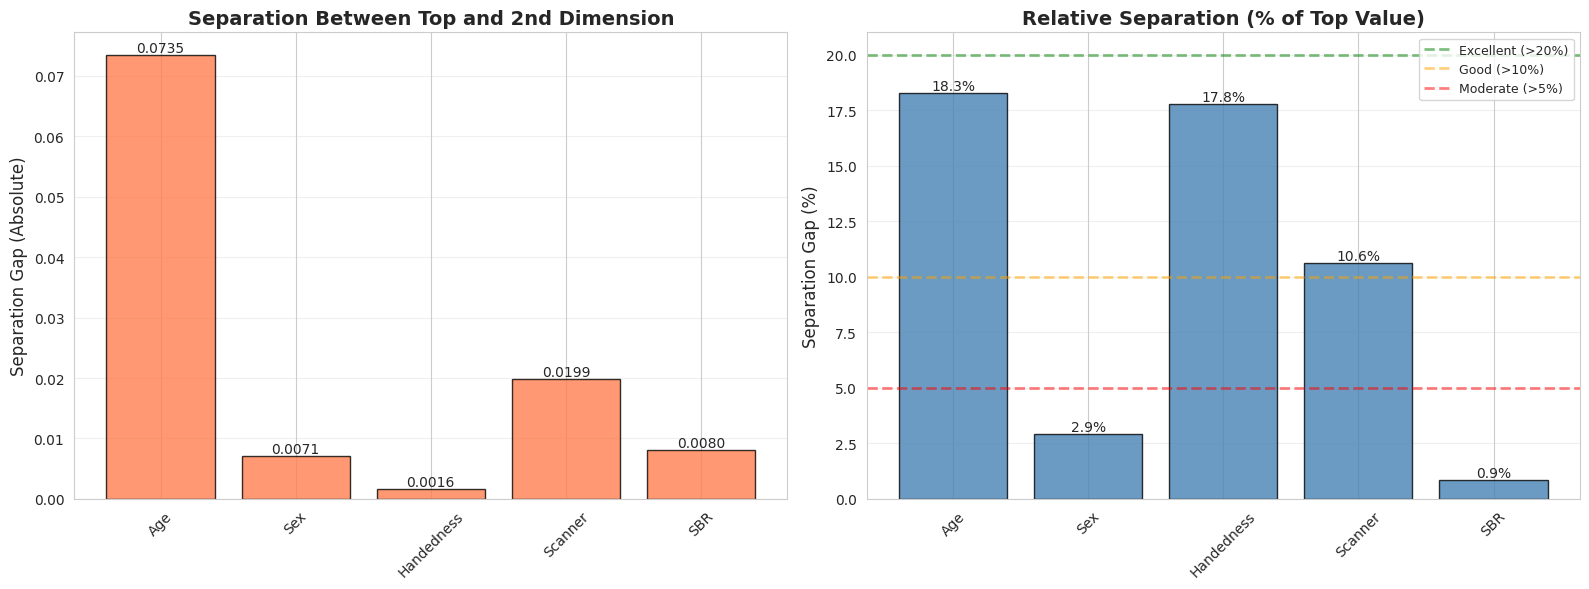

Plot saved to: output/dimension_factor_separation_gaps.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Absolute gap
axes[0].bar(df_summary['Factor'], df_summary['Gap'], color='coral', edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Separation Gap (Absolute)', fontsize=12)
axes[0].set_title('Separation Between Top and 2nd Dimension', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for i, (factor, gap) in enumerate(zip(df_summary['Factor'], df_summary['Gap'])):
    axes[0].text(i, gap, f'{gap:.4f}', ha='center', va='bottom', fontsize=10)

# Plot 2: Relative gap (percentage)
axes[1].bar(df_summary['Factor'], df_summary['Gap_Percent'], color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Separation Gap (%)', fontsize=12)
axes[1].set_title('Relative Separation (% of Top Value)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for i, (factor, gap_pct) in enumerate(zip(df_summary['Factor'], df_summary['Gap_Percent'])):
    axes[1].text(i, gap_pct, f'{gap_pct:.1f}%', ha='center', va='bottom', fontsize=10)

# Add threshold lines
axes[1].axhline(y=20, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Excellent (>20%)')
axes[1].axhline(y=10, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Good (>10%)')
axes[1].axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Moderate (>5%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('output/dimension_factor_separation_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_separation_gaps.png")

### 4.4 Visualization: Heatmap of Top Dimensions

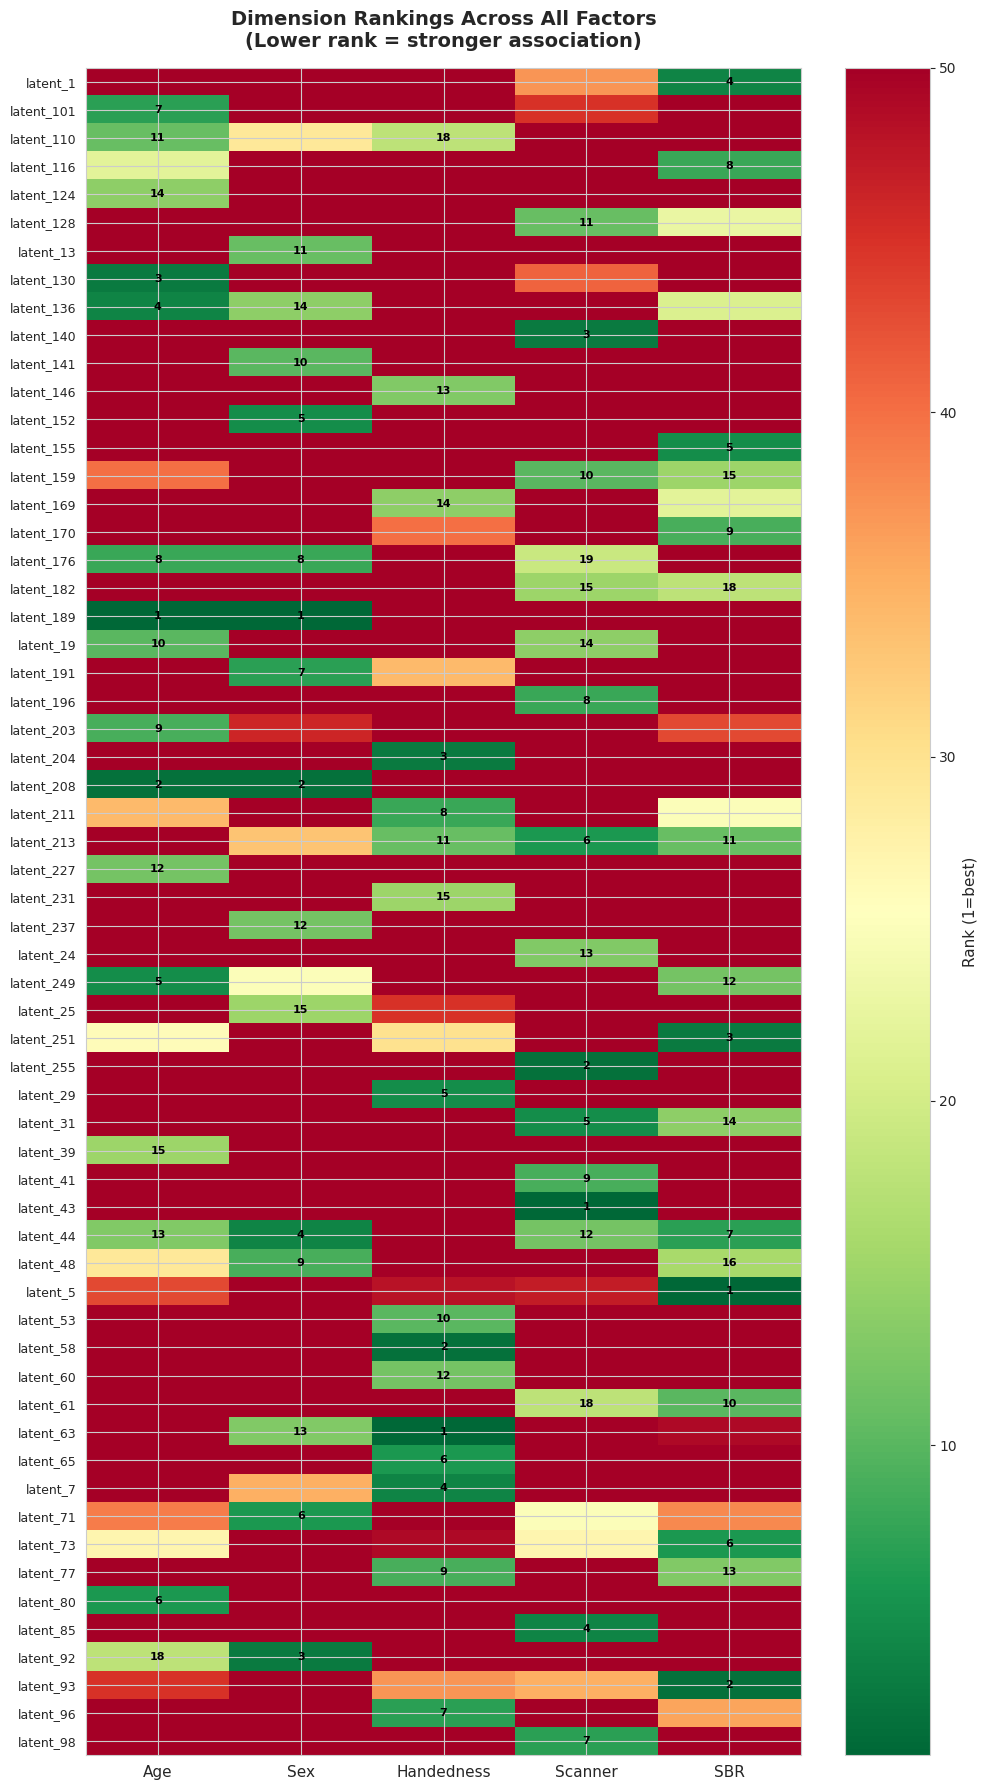

Plot saved to: output/dimension_factor_ranking_heatmap.png


In [24]:
# Create a matrix showing top dimensions for each factor
top_n_display = 15

# Collect all top dimensions
all_top_dims = set()
factor_rankings = {}

for factor_name, df_corr, sep, metric_col in plot_data:
    if df_corr is None:
        continue
    top_dims = df_corr.head(top_n_display)['Feature'].tolist()
    all_top_dims.update(top_dims)
    factor_rankings[factor_name] = {row['Feature']: row['Rank'] for _, row in df_corr.iterrows()}

all_top_dims = sorted(list(all_top_dims))

# Create ranking matrix
ranking_matrix = []
factor_names = [name for name, _, _, _ in plot_data if name in factor_rankings]

for dim in all_top_dims:
    row = []
    for factor_name in factor_names:
        rank = factor_rankings[factor_name].get(dim, 257)  # 257 if not in top rankings
        row.append(rank)
    ranking_matrix.append(row)

ranking_matrix = np.array(ranking_matrix)

# Create heatmap
fig, ax = plt.subplots(figsize=(10, max(8, len(all_top_dims) * 0.3)))

# Use reversed colormap so rank 1 is darkest
im = ax.imshow(ranking_matrix, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=50)

# Set ticks
ax.set_xticks(range(len(factor_names)))
ax.set_xticklabels(factor_names, fontsize=11)
ax.set_yticks(range(len(all_top_dims)))
ax.set_yticklabels(all_top_dims, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Rank (1=best)', fontsize=11)

# Add rank values to cells (only for top 20)
for i in range(len(all_top_dims)):
    for j in range(len(factor_names)):
        rank = ranking_matrix[i, j]
        if rank <= 20:
            text = ax.text(j, i, f'{int(rank)}',
                          ha="center", va="center", color="black", fontsize=8, fontweight='bold')

ax.set_title('Dimension Rankings Across All Factors\n(Lower rank = stronger association)', 
            fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('output/dimension_factor_ranking_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_ranking_heatmap.png")

## Section 5: Save Results

### 5.1 Save Correlation Results

In [25]:
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# Save individual correlation results
df_age_corr.to_csv(output_dir / 'dimension_correlations_age.csv', index=False)
df_sex_corr.to_csv(output_dir / 'dimension_correlations_sex.csv', index=False)
if df_hand_corr is not None:
    df_hand_corr.to_csv(output_dir / 'dimension_correlations_handedness.csv', index=False)
df_scanner_corr.to_csv(output_dir / 'dimension_correlations_scanner.csv', index=False)
df_sbr_corr.to_csv(output_dir / 'dimension_correlations_sbr.csv', index=False)

# Save summary
df_summary.to_csv(output_dir / 'dimension_factor_summary.csv', index=False)

print("Results saved to:")
print(f"  - {output_dir / 'dimension_correlations_age.csv'}")
print(f"  - {output_dir / 'dimension_correlations_sex.csv'}")
if df_hand_corr is not None:
    print(f"  - {output_dir / 'dimension_correlations_handedness.csv'}")
print(f"  - {output_dir / 'dimension_correlations_scanner.csv'}")
print(f"  - {output_dir / 'dimension_correlations_sbr.csv'}")
print(f"  - {output_dir / 'dimension_factor_summary.csv'}")

Results saved to:
  - output/dimension_correlations_age.csv
  - output/dimension_correlations_sex.csv
  - output/dimension_correlations_handedness.csv
  - output/dimension_correlations_scanner.csv
  - output/dimension_correlations_sbr.csv
  - output/dimension_factor_summary.csv


### 5.2 Final Summary

In [26]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

print("\nKey Findings:")
print("-" * 80)

for _, row in df_summary.iterrows():
    quality = "EXCELLENT" if row['Gap_Percent'] > 20 else "GOOD" if row['Gap_Percent'] > 10 else "MODERATE" if row['Gap_Percent'] > 5 else "WEAK"
    
    print(f"\n{row['Factor']}:")
    print(f"  Top Dimension: {row['Top_Dimension']}")
    print(f"  {row['Metric']}: {row['Top_Value']:.4f}")
    print(f"  Separation: {quality} ({row['Gap_Percent']:.1f}% gap from 2nd-best)")
    print(f"  Statistical significance: p={row['P_Value']:.4e}")

print("\n" + "="*80)
print("All results and visualizations saved to output/ directory")
print("="*80)


ANALYSIS COMPLETE

Key Findings:
--------------------------------------------------------------------------------

Age:
  Top Dimension: latent_189
  Pearson r: 0.4030
  Separation: GOOD (18.3% gap from 2nd-best)
  Statistical significance: p=9.8853e-92

Sex:
  Top Dimension: latent_189
  Point-biserial r: 0.2401
  Separation: WEAK (2.9% gap from 2nd-best)
  Statistical significance: p=6.3475e-32

Handedness:
  Top Dimension: latent_63
  Eta²: 0.0089
  Separation: GOOD (17.8% gap from 2nd-best)
  Statistical significance: p=3.1872e-05

Scanner:
  Top Dimension: latent_43
  Eta²: 0.1868
  Separation: GOOD (10.6% gap from 2nd-best)
  Statistical significance: p=1.5147e-93

SBR:
  Top Dimension: latent_5
  Pearson r: 0.9317
  Separation: WEAK (0.9% gap from 2nd-best)
  Statistical significance: p=0.0000e+00

All results and visualizations saved to output/ directory
